# Using ES(1+1) 1/5 to find optimal hyperparameters for XOR3 model

##3 classes

<pre>
   | x0 | x1 |XOR3|
   |----|----|----|
   |0.0 |0.0 | 0  |
   |0.0 |1.0 | 1  |
   |1.0 |0.0 | 1  |
   |1.0 |1.0 | 0  |
   |0.5 |0.5 | 2  |
</pre>

Hyper parameters to optimize
- number of hidden neurons
- learning rate
- batch size
- num epochs
- activation function
- optimizer algorithm

### 0: num_neurons, 1: lr, 2: bsize, 3: mum epochs, 4: actfun, 5: optmzr

CJ Chung, Feb 2022, Sep 2025

License CC BY 4.0:
The CC BY 4.0 license allows anyone to share, adapt, and use the licensed work for any purpose, as long as they give appropriate credit to the original creator.

In [ ]:
act_func = ('relu', 'elu', 'sigmoid', 'tanh', 'leaky_relu') # put highly selectable fn in the center

<img src=https://miro.medium.com/v2/resize:fit:720/format:webp/1*RD0lIYqB5L2LrI2VTIZqGw.png width=400>

In [ ]:
optimz = ('SGD', 'RMSprop', 'Adam') # put highly selectable fn in the center

In [ ]:
from keras.models import Sequential
from keras.layers import Dense, Dropout, Activation
from keras import optimizers
from keras.models import save_model, load_model
import matplotlib.pyplot as plt
import numpy as np
import keras

# the five different states of the XOR3 gate
X = np.array([[0,0],[0,1],[1,0],[1,1],[0.5,0.5]])

# the five expected results in the same order
y = np.array([[0],[1],[1],[0],[2]])

Xt = np.array([[0,0.1],[0.1,1],[0.9,0],[0.9,1],[0.55,0.45]])
yt = np.array([[0],[1],[1],[0],[2]])

# 0: num_neurons,    1: lr,    2: bsize,    3: mum epochs,  4: act_fn,  5: optmzr

def XOR3_eval(param):
  global model

  model = Sequential([
    keras.Input(shape=(2,)),
    Dense(int(param[0]), activation=act_func[ int(param[4]) ]),
    Dense(3, activation='softmax')
  ])
  if ( int(param[5]) == 0 ):
    optmzr = optimizers.SGD(learning_rate=param[1]) # stochastic gradient decent
  elif ( int(param[5]) == 1 ):
    optmzr = optimizers.RMSprop(learning_rate=param[1])
  elif ( int(param[5]) == 2 ):
    optmzr = optimizers.Adam(learning_rate=param[1])

  model.compile(loss='sparse_categorical_crossentropy', optimizer=optmzr, metrics=['accuracy'])
  model.fit(X, y, batch_size=int(param[2]), epochs=int(param[3]), verbose=0)
  (loss, acc) = model.evaluate(Xt, yt, verbose=0)

  return loss

In [ ]:
# to test a set of parameters
# 0: num_neurons,   1: lr,    2: bsize,    3: mum epochs,  4: act_fn,  5: optmzr
pr = np.empty(6)
pr[0] = 6   # num hidden neuron
pr[1] = 1.5 # lr
pr[2] = 1   # batch size
pr[3] = 100 # epochs
pr[4] = 2   # ('relu', 'elu', 'sigmoid', 'tanh', 'leaky_relu')
pr[5] = 1   # ('SGD', 'RMSprop', 'Adam')
print(XOR3_eval(pr))

2.4403951168060303


In [ ]:
# Constants
MaxGen = 35
MaxTrial = 3
numVar = 6

In [ ]:
#@title testing Python np basics
x1 = np.array([1,2,3,4])
y1 = np.array([2,3,4,5])
def func(xy):
  return xy[0]*xy[1]
func([x1,y1])

array([ 2,  6, 12, 20])

In [ ]:
#@title test random generators, integer numbers between 1 and 9
np.random.seed(1)
#for _ in range(20):
  #print(round(np.random.uniform(1, 10)))

In [ ]:
#@title test random generators, float numbers between 0.01 ~ 1.50
np.random.seed(1)
print(round(1.2345, 2))
#for _ in range(20):
  #print(round(np.random.uniform(0.01, 1.5), 2))

1.23


In [ ]:
#@title test normal random generators
np.random.seed()
#for _ in range(20):
  #print(round(np.random.normal(0.0, 0.82)))

In [ ]:
# num_neurons, lr, actfun, bsize, lossfun, optmzr
def print_HP_found(x, eval):
  print(f"#neurons={int(x[0])}, lr={x[1]:.3f}, bsize={int(x[2])}, #epochs={int(x[3])}, actF={act_func[int(x[4])]},  optim={optimz[int(x[5])]}")
  print(f"Eval={eval}")

In [ ]:
import matplotlib.pyplot as plt
def draw_plot(m):
    # To display 4 training inputs
    xpoint = np.array([])
    ypoint = np.array([])
    for i in X:
        xpoint = np.append(xpoint, i[0])
        ypoint = np.append(ypoint, i[1])

    #print ("xpoints:", xpoint)
    #print ("ypoints:", ypoint)

    xp_zero = np.array([])
    yp_zero = np.array([])
    xp_one = np.array([])
    yp_one = np.array([])
    xp_two = np.array([])
    yp_two = np.array([])
    numZero = 0
    numOne = 0
    numTwo = 0

    for x in np.arange(0.0, 1.05, 0.05): # cannot use range since start and stop must be int
      for y in np.arange(0.0, 1.05, 0.05):
        #xp = np.append(xp,x)
        #yp = np.append(yp,y)
        xy = np.array([[x,y]])
        out = np.argmax(m.predict(xy, verbose=0))
        if out == 1:
            xp_one = np.append(xp_one,y)
            yp_one = np.append(yp_one,x)
            numOne += 1
        elif out == 0:
            xp_zero = np.append(xp_zero, x)
            yp_zero = np.append(yp_zero, y)
            numZero += 1
        else:
            xp_two = np.append(xp_two, x)
            yp_two = np.append(yp_two, y)
            numTwo += 1

    #print ("xp:", xp)
    #print ("yp:", yp)

    # -------- PLOT the graph -----
    plt.plot(xpoint, ypoint, 'ks') # to plot 4 points in x. k is for black
    plt.plot(xp_zero, yp_zero, 'b.') # to plot all non-fired points
    plt.plot(xp_one, yp_one, 'r*') # to plot all fired points
    #plt.plot(xp_two, yp_two, 'y*') # to plot all fired points
    plt.show() # Show the figure
    totTestPoints = numZero + numOne + numTwo
    print (f" Blue % = {numZero/totTestPoints*100}")
    print (f"  Red % = {numOne/totTestPoints*100}")
    print (f"White % = {numTwo/totTestPoints*100}")



In [ ]:
def es1115(objfunc, hparams, numVar, MaxGen, WindowSize, stepSize_i, stepSize_r):

    xp = np.empty(numVar) # parent
    p_val = 0
    xo = np.empty(numVar) # offspring
    o_val = 0

    successCnt = 0;

    # Assign initial values to parent. We could use uniform ramdom numbers...
    for i in range(numVar):
        xp[i] = hparams[i][0]

    p_val = objfunc(xp)     # evaluate the parent

    stepSize = stepSize_i

    for g in range(1, MaxGen+1):
        # Test later if this step size can be place at the end of the loop part
        if (g % WindowSize) == 0: # update stepsize
            if successCnt > (WindowSize * 0.2):
                stepSize = stepSize / stepSize_r #increase
            elif successCnt < (WindowSize * 0.2):
                stepSize = stepSize * stepSize_r #decrease
            #else do not change stepSize
            #print(successCnt, stepSize)
            successCnt = 0

        # mutate each hyperparameter
        for i in range(numVar):
            stepSize_scaled = stepSize*(hparams[i][2]-hparams[i][1])
            xo[i] = xp[i] + round(np.random.normal(0.0, stepSize_scaled), 2 if i == 1 else 0) # Apply rounding to 2 decimal places only for learning rate (index 1)
            # to correct if any variation goes out of acceptable range
            xo[i] = np.clip(xo[i], hparams[i][1], hparams[i][2]) # hparams[i][1]: lower_bound. clip fn lower upper both inclusive

        o_val = objfunc(xo)  # evaluate offspring

        # select
        if o_val < p_val:
            #xp = xo # No! must maintain two separate spaces
            xp = xo.copy()
            p_val = o_val
            successCnt += 1;
            #print(xp, p_val, successCnt, stepSize)

        if p_val < 0.01: # we assume minima is zero.
            return xp, p_val, g, True

    return xp, p_val, MaxGen, False


************************** Trial # = 1
Acceptable solution found after 31 generations:
#neurons=4, lr=1.260, bsize=1, #epochs=228, actF=elu,  optim=RMSprop
Eval=1.907348234908568e-07


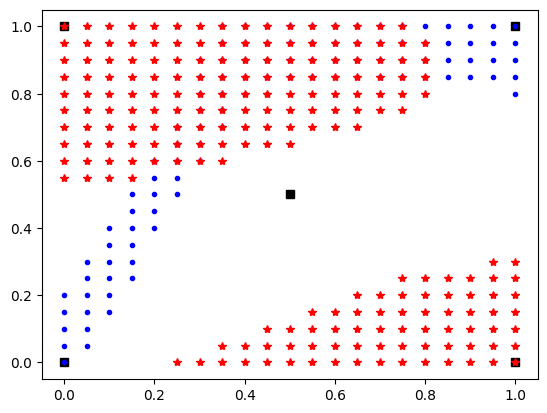

 Blue % = 23.12925170068027
  Red % = 46.48526077097506
White % = 30.385487528344672
best_p_val = 1.907348234908568e-07

************************** Trial # = 2
Acceptable solution found after 14 generations:
#neurons=10, lr=0.080, bsize=5, #epochs=100, actF=leaky_relu,  optim=Adam
Eval=0.008899384178221226


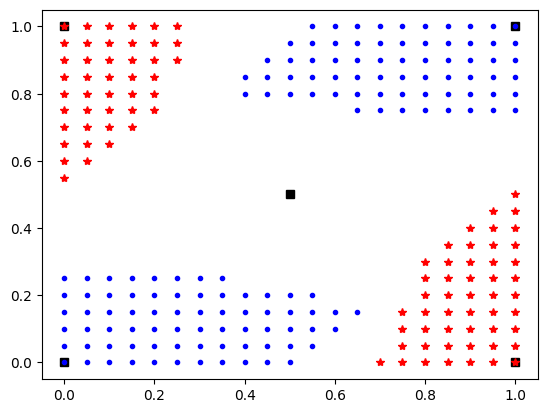

 Blue % = 31.065759637188208
  Red % = 21.08843537414966
White % = 47.84580498866213

************************** Trial # = 3
Acceptable solution found after 6 generations:
#neurons=12, lr=1.500, bsize=3, #epochs=376, actF=tanh,  optim=SGD
Eval=0.008124081417918205


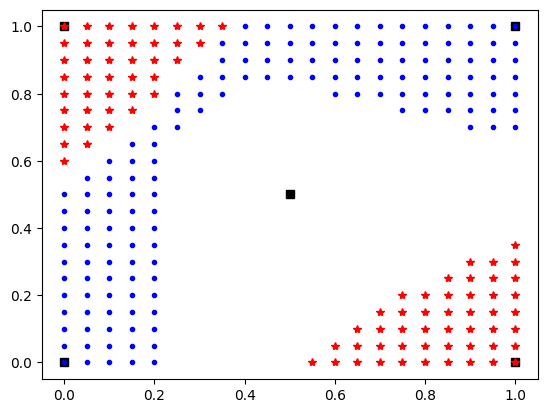

 Blue % = 32.87981859410431
  Red % = 20.181405895691608
White % = 46.93877551020408

System Success = 100.0%
Avgerage # of generations used = 17


In [ ]:
# Constants
MaxGen = 35
MaxTrial = 3
numVar = 6

totgen = 0
foundCnt = 0  # acceptable solution found
objfunc = XOR3_eval #
#np.random.seed(1) # makes the random numbers predictable to debug

# for 1/5 rule
stepSize_i = 0.82 # initial stepsize
stepSize_r = 0.82 # stepsize change ratio.
                  # 0.82 was used previously by Hans-Paul Schwefel, a PhD student of Rechenberg
WindowSize = 10

# for 1/5 rule
stepSize_i = 0.82 # initial stepsize
stepSize_r = 0.82 # stepsize change ratio.
                  # 0.82 was used previously by Hans-Paul Schwefel, a PhD student of Rechenberg

best_p_val = 9999 # a large number

for trial in range(0, MaxTrial):
    # initialize hyper parameters using tuples (initial_value, lower_bound, upper_bound)
    hparams = [
        (3, 2, 16),   # num hidden neuron, low_b, high_b
        (round(np.random.uniform(0.01, 1.5), 2), 0.01, 1.5), # lr
        (2, 1, 5),   # batch size
        (100, 100, 500),   # num epochs
        (2, 0, 4),   # ('relu', 'elu', 'sigmoid', 'tanh', 'leaky_relu')
        (1, 0, 2)    # optimizers: ('SGD', 'RMSprop', 'Adam')
    ]

    print(f"\n************************** Trial # = {trial+1}")

    xp, p_val, generations, success = es1115(objfunc, hparams, numVar, MaxGen, WindowSize, stepSize_i, stepSize_r)

    if success:
        print(f"Acceptable solution found after {generations} generations:")
        foundCnt += 1
        print_HP_found(xp, p_val)
        draw_plot(model)
        if p_val < best_p_val:
            best_p_val = p_val
            print(f"best_p_val = {best_p_val}")
            #save_model(model, 'best' + str(p_val) + '.keras')
            save_model(model, 'bestXOR3.keras')
    totgen += generations

print(f"\nSystem Success = {foundCnt/MaxTrial*100}%")
print(f"Avgerage # of generations used = {(totgen/MaxTrial):,.0f}")

Model: "sequential_38"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_76 (Dense)                │ (None, 4)              │            12 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_77 (Dense)                │ (None, 3)              │            15 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 56 (228.00 B)

 Trainable params: 27 (108.00 B)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 29 (120.00 B)

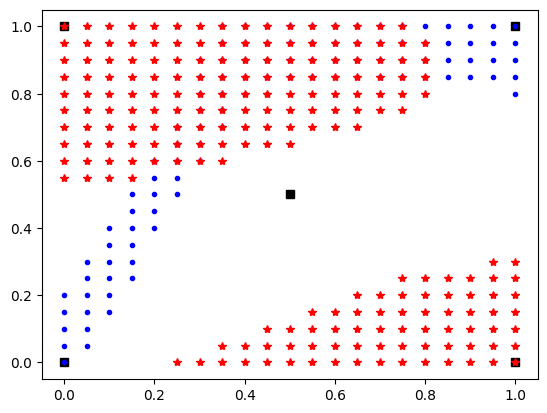

 Blue % = 23.12925170068027
  Red % = 46.48526077097506
White % = 30.385487528344672


In [ ]:
m1=load_model('bestXOR3.keras')
m1.summary()
draw_plot(m1)